Dynamic EV charging prices will respond to this signals: reatail_price, demand (energy_sold_kwh), and peak hour

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dynamic_df = pd.read_csv('model.csv')

In [3]:
dynamic_df.head()

,session_id,datetime,hour,day_of_week,is_weekend,temperature,wholesale_price,retail_price,charging_sessions,energy_per_session,energy_sold_kwh,predicted_energy_sold_kwh
0,1,2025-01-01 00:00:00,0,2,0,25.127134,0.188319,0.235398,5,13.923257,69.616286,106.850447
1,2,2025-01-01 01:00:00,1,2,0,25.190453,0.182241,0.227801,3,25.697249,77.091747,63.715196
2,3,2025-01-01 02:00:00,2,2,0,27.573437,0.206828,0.258534,1,25.714565,25.714565,24.707828
3,4,2025-01-01 03:00:00,3,2,0,28.977748,0.198582,0.248228,2,20.320314,40.640627,50.080246
4,5,2025-01-01 04:00:00,4,2,0,28.294179,0.208094,0.260118,2,24.234807,48.469613,48.107129


Demand Multiplier (demand increases, price increases)

In [4]:
# Normalize demand
dynamic_df["normalized_demand"] = dynamic_df["predicted_energy_sold_kwh"] / dynamic_df["predicted_energy_sold_kwh"].max()

# Demand multiplier
dynamic_df["demand_multiplier"] = 1 + (dynamic_df["normalized_demand"] * 0.5) #Demand can increase price up to 50%.

Peak hour multiplier

In [5]:
dynamic_df["time_multiplier"] = np.where(
    dynamic_df["hour"].between(17,21), 1.30,
    np.where(dynamic_df["hour"].between(7,9), 1.20, 1)
)

#adds 30% percent increase in price between (5 - 7) pm and 20% between (7-9) am.

Calculate Dynamic price

In [6]:
dynamic_df["dynamic_price"] = (
    dynamic_df["retail_price"]
    * dynamic_df["demand_multiplier"]
    * dynamic_df["time_multiplier"]
)

Apply Price Safety Limits.
We don't want a drastic increase in price 

In [7]:
dynamic_df["dynamic_price"] = dynamic_df["dynamic_price"].clip(
    lower=dynamic_df["retail_price"] * 1.05,
    upper=dynamic_df["retail_price"] * 2
)

#the maximum price should not exceed retail_price * 2, and the minimum price should be a 5% increase

In [8]:
dynamic_df.head()

,session_id,datetime,hour,day_of_week,is_weekend,temperature,wholesale_price,retail_price,charging_sessions,energy_per_session,energy_sold_kwh,predicted_energy_sold_kwh,normalized_demand,demand_multiplier,time_multiplier,dynamic_price
0,1,2025-01-01 00:00:00,0,2,0,25.127134,0.188319,0.235398,5,13.923257,69.616286,106.850447,0.334125,1.167063,1.0,0.274725
1,2,2025-01-01 01:00:00,1,2,0,25.190453,0.182241,0.227801,3,25.697249,77.091747,63.715196,0.199240,1.099620,1.0,0.250495
2,3,2025-01-01 02:00:00,2,2,0,27.573437,0.206828,0.258534,1,25.714565,25.714565,24.707828,0.077262,1.038631,1.0,0.271461
3,4,2025-01-01 03:00:00,3,2,0,28.977748,0.198582,0.248228,2,20.320314,40.640627,50.080246,0.156603,1.078301,1.0,0.267665
4,5,2025-01-01 04:00:00,4,2,0,28.294179,0.208094,0.260118,2,24.234807,48.469613,48.107129,0.150433,1.075216,1.0,0.279683


In [9]:
static_df = pd.read_csv('static_pricing_data.csv')
static_df.head()

,session_id,static_markup_percent,static_retail_price,static_revenue,static_cost,static_profit
0,1,0.25,0.1876,20.045131,20.121945,-0.076814
1,2,0.25,0.1876,11.952963,11.611514,0.341449
2,3,0.25,0.1876,4.635186,5.110260,-0.475075
3,4,0.25,0.1876,9.395048,9.945060,-0.550012
4,5,0.25,0.1876,9.024892,10.010820,-0.985928


In [10]:
static_df['static_profit'].sum()

16625.622784405736

Dynamic Pricing with demand elasticity

we add a negative elasticity as some people will not react well to price increase

In [11]:
elasticity = -0.4   # negative demand elasticity, as increase in price might affect demand (energy_sold_kwh)
Price_change = (dynamic_df['dynamic_price']  - static_df['static_retail_price']) / static_df['static_retail_price']
dynamic_df['Adjusted_demand_kwh'] = dynamic_df['predicted_energy_sold_kwh'] * (1 + elasticity * Price_change)

In [12]:
dynamic_df['dynamic_revenue'] = dynamic_df['dynamic_price'] * dynamic_df['Adjusted_demand_kwh']  #revenue with elasticity
dynamic_df['dynamic_cost'] = dynamic_df['wholesale_price'] * dynamic_df['Adjusted_demand_kwh']
dynamic_df['dynamic_profit'] = dynamic_df['dynamic_revenue'] - dynamic_df['dynamic_cost']

print(f"dynamic_profit : {dynamic_df['dynamic_profit'].sum()}")

dynamic_profit : 31675.92289391986


Comparing static Profit with dynamic profit (profit with dynamic pricing)

Profit increase percent

In [13]:
total_static_profit = static_df["static_profit"].sum()
total_dynamic_profit = dynamic_df["dynamic_profit"].sum()

In [14]:
profit_increase_percent = (
    (total_dynamic_profit - total_static_profit) 
    / total_static_profit
) * 100

print("Static Profit: $", round(total_static_profit,2))
print("Dynamic Profit: $", round(total_dynamic_profit,2))
print("Profit Increase:", round(profit_increase_percent,2), "%")

Static Profit: $ 16625.62
Dynamic Profit: $ 31675.92
Profit Increase: 90.52 %


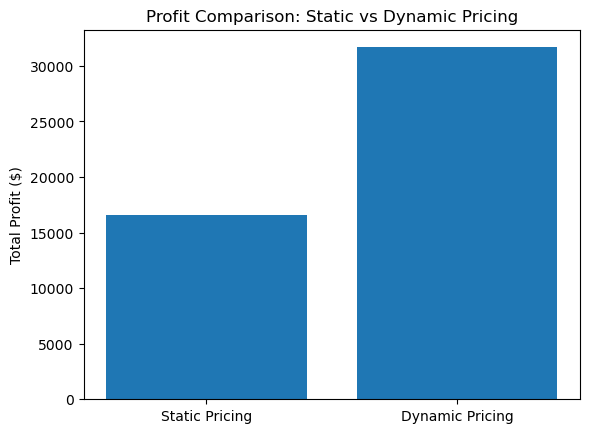

In [15]:
profits = [total_static_profit, total_dynamic_profit]
labels = ["Static Pricing", "Dynamic Pricing"]

plt.bar(labels, profits)
plt.ylabel("Total Profit ($)")
plt.title("Profit Comparison: Static vs Dynamic Pricing")

plt.show()

The simulation showed a 90.52% profit increase under dynamic pricing. This large improvement occurs because the static pricing model applies a fixed 20% margin regardless of demand, while the dynamic pricing model adjusts prices during peak charging periods

Merging dataframes 

In [16]:
ev_dynamic_pricing_data = dynamic_df.merge(static_df, on = 'session_id')

In [ ]:
ev_dynamic_pricing_data.head()

,session_id,datetime,hour,day_of_week,is_weekend,temperature,wholesale_price,retail_price,charging_sessions,energy_per_session,...,dynamic_price,Adjusted_demand_kwh,dynamic_revenue,dynamic_cost,dynamic_profit,static_markup_percent,static_retail_price,static_revenue,static_cost,static_profit
0,1,2025-01-01 00:00:00,0,2,0,25.127134,0.188319,0.235398,5,13.923257,...,0.274725,87.001109,23.901360,16.383942,7.517417,0.25,0.1876,20.045131,20.121945,-0.076814
1,2,2025-01-01 01:00:00,1,2,0,25.190453,0.182241,0.227801,3,25.697249,...,0.250495,55.170729,13.819972,10.054363,3.765609,0.25,0.1876,11.952963,11.611514,0.341449
2,3,2025-01-01 02:00:00,2,2,0,27.573437,0.206828,0.258534,1,25.714565,...,0.271461,20.289849,5.507907,4.196500,1.311406,0.25,0.1876,4.635186,5.110260,-0.475075
3,4,2025-01-01 03:00:00,3,2,0,28.977748,0.198582,0.248228,2,20.320314,...,0.267665,41.530845,11.116342,8.247298,2.869043,0.25,0.1876,9.395048,9.945060,-0.550012
4,5,2025-01-01 04:00:00,4,2,0,28.294179,0.208094,0.260118,2,24.234807,...,0.279683,38.661801,10.813049,8.045301,2.767749,0.25,0.1876,9.024892,10.010820,-0.985928


In [21]:
ev_dynamic_pricing_data.columns

Index(['session_id', 'datetime', 'hour', 'day_of_week', 'is_weekend',
       'temperature', 'wholesale_price', 'retail_price', 'charging_sessions',
       'energy_per_session', 'energy_sold_kwh', 'predicted_energy_sold_kwh',
       'normalized_demand', 'demand_multiplier', 'time_multiplier',
       'dynamic_price', 'Adjusted_demand_kwh', 'dynamic_revenue',
       'dynamic_cost', 'dynamic_profit', 'static_markup_percent',
       'static_retail_price', 'static_revenue', 'static_cost',
       'static_profit'],
      dtype='object')

In [22]:
ev_dynamic_pricing_data.to_csv("ev_dynamic_pricing_data.csv", index= False)

In [18]:
# ev_dynamic_pricing_data.to_excel("ev_dynamic_pricing_data.xlsx", index=False)

#for financial modelling in excel

separating Charging data from dynamic dataframe for sql dynamic pricing table

In [19]:
dynamic_pricing_df = dynamic_df[['session_id', 'dynamic_price', 'predicted_energy_sold_kwh', 'Adjusted_demand_kwh', 'dynamic_revenue', 'dynamic_profit' ]]
    

In [20]:
dynamic_pricing_df.to_csv('dynamic_pricing.csv', index=False)